In [9]:
import numpy as np
import pandas as pd
import alphashape
import pyvista as pv
import matplotlib.pyplot as plt

In [17]:
def calculate_single_tree_metrics(group, alpha_2d=0.3, alpha_3d=0.6):
    x, y, z = group["x"].values, group["y"].values, group["z"].values

    # I want to get the max height and the min height of the point cloud
    tree_height = z.max() - z.min()
    max_height = z.max()
    min_height = z.min()

    # 1. Zero-center coordinates to prevent floating point scale distortions
    x_centered = x - x.mean()
    y_centered = y - y.mean()
    z_centered = z - z.min()

    points_2d_centered = np.column_stack((x_centered, y_centered))
    points_3d_centered = np.column_stack((x_centered, y_centered, z_centered))

    # 2D Crown Area & Diameter (Alpha Shape)
    try:
        alpha_shape_2d = alphashape.alphashape(points_2d_centered, alpha_2d)
        crown_area_2d = alpha_shape_2d.area
    except Exception:
        crown_area_2d = np.nan

    crown_diameter = (
        2 * np.sqrt(crown_area_2d / np.pi)
        if pd.notna(crown_area_2d)
        else np.nan
    )

    # 3D Crown Volume (Alpha Wrap via PyVista)
    try:
        cloud = pv.PolyData(points_3d_centered)
        # Note: You may need to tune alpha_3d (e.g. between 0.5 and 2.0 depending on point density)
        mesh = cloud.delaunay_3d(alpha=alpha_3d).extract_geometry()
        crown_volume_3d = mesh.volume
    except Exception:
        crown_volume_3d = np.nan

    return {
        "treeID": group["treeID"].iloc[0] if "treeID" in group else 0,
        "point_count": len(group),
        "tree_height": tree_height,
        "max_height": max_height,
        "min_height": min_height,
        "crown_area_2d": crown_area_2d,
        "crown_diameter": crown_diameter,
        "crown_volume_3d": crown_volume_3d,
    }

df = pd.read_csv("C:\\Floor\\Documenten\\ENV-year-2\\Thesis\\Data\\oud\\segmentation.xyz", sep=r"\s+", names=["treeID", "x", "y", "z"])


In [18]:
results_df = pd.DataFrame()

for i in range(len(df["treeID"].unique())):
    tree_points = df[df["treeID"] == i]
    tree_metrics = calculate_single_tree_metrics(tree_points, alpha_2d=0.3, alpha_3d=0.6)
    results_df = pd.concat([results_df, pd.DataFrame([tree_metrics])], ignore_index=True)

#add the location of the trees to the results dataframe
tree_locations = df.groupby("treeID")[["x", "y"]].mean().reset_index()
results_df = results_df.merge(tree_locations, on="treeID", how="left")

C:\Users\hoeks\AppData\Local\Temp\ipykernel_19792\3919345646.py:34: PyVistaDeprecationWarning: `extract_geometry` is deprecated. Use `extract_surface(algorithm=None)` instead.
  mesh = cloud.delaunay_3d(alpha=alpha_3d).extract_geometry()


In [19]:
results_df


,treeID,point_count,tree_height,max_height,min_height,crown_area_2d,crown_diameter,crown_volume_3d,x,y
0,0,5613,10.17,17.25,7.08,140.82185,13.390293,298.955312,81556.230167,453945.064053
1,1,7595,13.73,17.05,3.32,211.55365,16.412144,270.239609,81547.474822,453899.413213
2,2,4962,12.09,16.72,4.63,122.39675,12.483605,204.056847,81558.414615,453879.342747
3,3,6676,15.42,16.77,1.35,99.50215,11.255668,109.579052,81389.579726,453932.586762
4,4,9341,16.12,17.43,1.31,125.50260,12.641000,228.175465,81368.870111,453916.651729
...,...,...,...,...,...,...,...,...,...,...
373,373,115,2.12,3.89,1.77,5.74995,2.705746,2.506005,81689.615652,454022.337304
374,374,113,2.44,3.77,1.33,6.07850,2.781975,3.276434,81609.838407,454083.111239
375,375,105,2.33,3.92,1.59,5.17635,2.567242,3.933649,81693.710571,453993.213524
376,376,62,2.07,3.53,1.46,2.63980,1.833330,2.468259,81410.616935,453753.719194


In [28]:
results_df["BKV"] = (results_df["crown_diameter"]/2) * (results_df["crown_diameter"]/2) * np.pi * (results_df["tree_height"]/2) * 4/3

#fine max bkv and which tree ID
max_bkv = results_df["BKV"].max()
max_bkv_tree_id = results_df[results_df["BKV"] == max_bkv]["treeID"].iloc[0]
max_bkv_tree_id
results_df[results_df["treeID"] == 12]

,treeID,point_count,tree_height,max_height,min_height,crown_area_2d,crown_diameter,crown_volume_3d,x,y,BKV
12,12,26396,13.77,15.32,1.55,879.3939,33.461606,617.291333,81434.787144,453761.342177,8072.836002


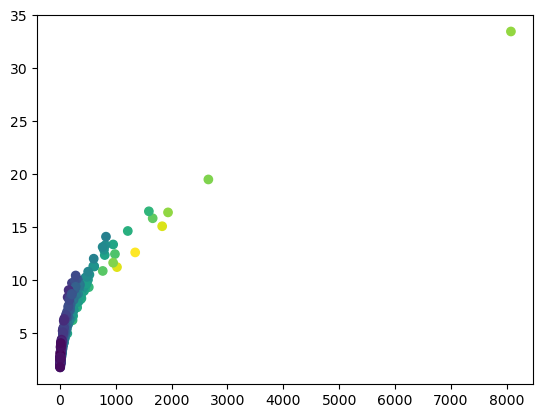

In [10]:
#visualize the BKV
plt.scatter(results_df["BKV"], results_df["crown_diameter"], c=results_df["tree_height"], cmap='viridis')

In [ ]:
# import geopandas as gpd
# from shapely.geometry import Point

# # Create Shapely geometries (X, Y, Z)
# geometry = [Point(xy) for xy in zip(results_df["x"], results_df["y"], results_df["tree_height"])]

# # Convert DataFrame to GeoDataFrame
# gdf = gpd.GeoDataFrame(results_df, geometry=geometry, crs="EPSG:4326")

# # Export directly to GeoJSON string or dict
# geojson_data = gdf.to_json()

# #save the GeoJSON data to a file
# with open("C:\\Floor\\Documenten\\ENV-year-2\\Thesis\\Data\\tree_metrics.geojson", "w") as f:
#     f.write(geojson_data)


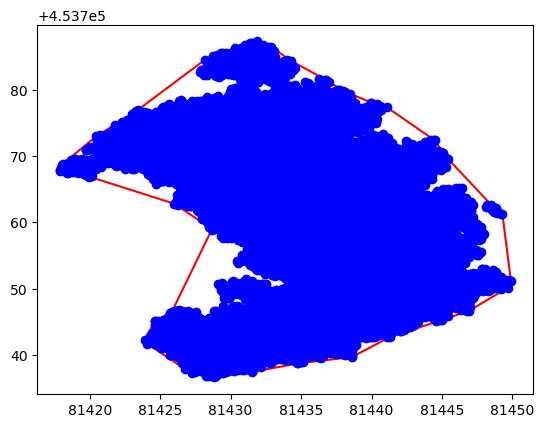

In [ ]:
import matplotlib.pyplot as plt
#visualize the alpha shape of the first tree
first_tree_points = df[df["treeID"] == 12]
alpha_shape_2d = alphashape.alphashape(first_tree_points[["x", "y"]].values, alpha=0.1)
plt.plot(*alpha_shape_2d.exterior.xy, color='red')
plt.plot(first_tree_points["x"], first_tree_points["y"], 'o', color='blue')

# for i in range(5):
#     tree_points = df[df["treeID"] == i]
#     alpha_shape_2d = alphashape.alphashape(tree_points[["x", "y"]].values, alpha=0.1)
#     plt.plot(tree_points["x"], tree_points["y"], 'o', color='blue')
#     plt.plot(*alpha_shape_2d.exterior.xy, color='red', linewidth=2)

#can i save these 2D alpha shapes as a shapefile or geojson file?
with open("C:\\Floor\\Documenten\\ENV-year-2\\Thesis\\Data\\alpha_shapes.geojson", "w") as f:
    f.write(alpha_shape_2d.to_json())
    

C:\Users\hoeks\AppData\Local\Temp\ipykernel_19792\3997300411.py:4: PyVistaDeprecationWarning: `extract_geometry` is deprecated. Use `extract_surface(algorithm=None)` instead.
  alpha_shape_3d = cloud.delaunay_3d(alpha=1).extract_geometry()
C:\Users\hoeks\AppData\Local\Temp\ipykernel_19792\3997300411.py:9: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  plotter.show()


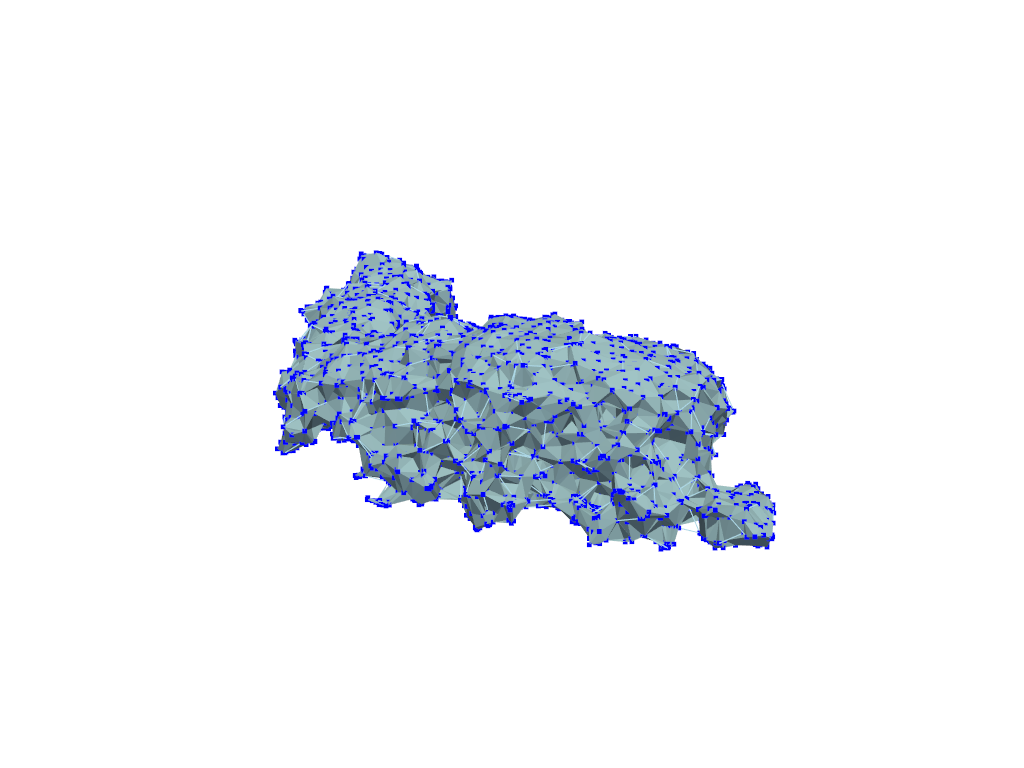

In [24]:
#in 3D
tree_points = df[df["treeID"] == 12]
cloud = pv.PolyData(tree_points[["x", "y", "z"]].values)
alpha_shape_3d = cloud.delaunay_3d(alpha=1).extract_geometry()
#plot in 3D
plotter = pv.Plotter()
plotter.add_mesh(alpha_shape_3d)
plotter.add_points(tree_points[["x", "y", "z"]].values, color='blue', point_size=5)
plotter.show()

#can you make it a 3D plot where i can rotate the tree and see the alpha shape from different angles


In [1]:
import geopandas as gpd
import numpy as np
from shapely.geometry import GeometryCollection, MultiPolygon, Polygon
from shapely.ops import voronoi_diagram

# 1. Laad de data
polygonen = gpd.read_file(
    r"C:\Floor\Documenten\ENV-year-2\Thesis\Data\oud\forest_hulls.geojson"
)
bomen_punten = gpd.read_file(
    r"C:\Floor\Documenten\ENV-year-2\Thesis\Data\bomen_denhaag.gpkg"
)

# Zorg voor gelijke projectie (bijv. EPSG:28992)
if polygonen.crs != bomen_punten.crs:
    bomen_punten = bomen_punten.to_crs(polygonen.crs)

# Geef de polygonen een uniek ID als dat er nog niet is
if "poly_id" not in polygonen.columns:
    polygonen["poly_id"] = polygonen.index

# 2. Ruimtelijke koppeling (welke bomen vallen in welke polygoon)
joined = gpd.sjoin(polygonen, bomen_punten, how="left", predicate="contains")

verbeterde_polygonen = []

# Groepeer per polygoon
for poly_idx, group in joined.groupby(joined.index):
    polygoon_row = polygonen.loc[poly_idx]
    polygoon = polygoon_row.geometry

    # Haal de unieke bomen op die binnen deze polygoon vallen
    valid_tree_indices = group["index_right"].dropna().unique()
    punten_in_poly = bomen_punten.loc[valid_tree_indices]
    aantal_bomen = len(punten_in_poly)

    # GEVAL 1: Geen boom in polygoon (ruis / valse detectie)
    if aantal_bomen == 0:
        # Optioneel: bewaar ze met een statusvlag
        # row_dict = polygoon_row.to_dict()
        # row_dict['status'] = 'geen_boom'
        # verbeterde_polygonen.append(row_dict)
        continue

    # GEVAL 2: Exact 1 boom -> Bewaar de polygoon en koppel boom_id
    elif aantal_bomen == 1:
        row_dict = polygoon_row.to_dict()
        row_dict["geometry"] = polygoon
        row_dict["boom_id"] = punten_in_poly.iloc[0].get(
            "id", punten_in_poly.index[0]
        )
        row_dict["status"] = "uniek"
        verbeterde_polygonen.append(row_dict)

    # GEVAL 3: Meerdere bomen -> Opsplitsen via Voronoi
    else:
        punten_union = punten_in_poly.unary_union

        # Gebruik de polygoon-envelope als grens voor de Voronoi-diagrammen
        voronoi_geoms = voronoi_diagram(
            punten_union, envelope=polygoon.envelope
        )

        for vor in voronoi_geoms.geoms:
            gesneden_kroon = vor.intersection(polygoon)

            if gesneden_kroon.is_empty:
                continue

            # Bepaal welke boom in deze specifieke Voronoi-cel hoort
            cel_boom_id = None
            for _, boom in punten_in_poly.iterrows():
                if vor.contains(boom.geometry) or vor.intersects(
                    boom.geometry
                ):
                    cel_boom_id = boom.get("id", boom.name)
                    break

            # Helper functie om polygonen toe te voegen (handelt ook MultiPolygon af)
            def voeg_poly_toe(geom):
                row_dict = polygoon_row.to_dict()
                row_dict["geometry"] = geom
                row_dict["boom_id"] = cel_boom_id
                row_dict["status"] = "opgesplitst"
                verbeterde_polygonen.append(row_dict)

            if isinstance(gesneden_kroon, Polygon):
                voeg_poly_toe(gesneden_kroon)
            elif isinstance(gesneden_kroon, MultiPolygon):
                # Explodeer MultiPolygon naar losse Polygonen
                for sub_poly in gesneden_kroon.geoms:
                    if not sub_poly.is_empty and sub_poly.area > 0.1:  # Filter hele kleine snippers
                        voeg_poly_toe(sub_poly)
            elif isinstance(gesneden_kroon, GeometryCollection):
                for sub_geom in gesneden_kroon.geoms:
                    if isinstance(sub_geom, (Polygon, MultiPolygon)):
                        if isinstance(sub_geom, Polygon):
                            voeg_poly_toe(sub_geom)
                        else:
                            for sub_poly in sub_geom.geoms:
                                voeg_poly_toe(sub_poly)

# 3. Exporteer resultaat
resultaat_gdf = gpd.GeoDataFrame(verbeterde_polygonen, crs=polygonen.crs)
resultaat_gdf.to_file(
    r"C:\Floor\Documenten\ENV-year-2\Thesis\Data\verbeterde_boom_polygonen.gpkg",
    driver="GPKG",
)

print(
    f"Klaar! Oorspronkelijk {len(polygonen)} segmenten -> Nieuw resultaat heeft {len(resultaat_gdf)} segmenten."
)

C:\Users\hoeks\AppData\Local\Temp\ipykernel_23288\2824871895.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  punten_union = punten_in_poly.unary_union
C:\Users\hoeks\AppData\Local\Temp\ipykernel_23288\2824871895.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  punten_union = punten_in_poly.unary_union
C:\Users\hoeks\AppData\Local\Temp\ipykernel_23288\2824871895.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  punten_union = punten_in_poly.unary_union
C:\Users\hoeks\AppData\Local\Temp\ipykernel_23288\2824871895.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  punten_union = punten_in_poly.unary_union
C:\Users\hoeks\AppData\Local\Temp\ipykernel_23288\2824871895.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_al

Klaar! Oorspronkelijk 599 segmenten -> Nieuw resultaat heeft 499 segmenten.
